In [27]:
from pathlib import Path
import pandas as pd

BASE = Path("..").resolve()
DATA = BASE / "Данные" / "Итоговые таблицы"

bank_statement_transactions = pd.read_parquet(DATA / "bank_statement_transactions.parquet")
sales_by_counterparties = pd.read_parquet(DATA / "sales_by_counterparties.parquet")
sales_by_payment_counterparties = pd.read_parquet(DATA / "sales_by_payment_counterparties.parquet")


In [28]:
sales_by_counterparties.head()


,counterparty_raw,legal_entity,brand,store_location_raw,city_or_area,contract_raw,contract_number,contract_date,sales_doc_raw,sales_doc_type,...,period_label,period_start,period_end,source_file,source_file_path,source_file_hash,source_sheet,source_row_number,source_quantity_column,source_amount_column
0,"Торгсервис 150 ООО Магазин Светофор г. Руза, п...",Торгсервис 150 ООО,Светофор,"г. Руза, п. Дорохово, ул. Невкипелого, д. 4.А",г. Руза,ТС-150/24-008МО2 от 09.02.2024,ТС-150/24-008МО2,2024-02-09,Корректировка реализации № 235 от 06.05.2025,Корректировка реализации,...,Продажи по контрагентам за Май 2025 г. - Июнь ...,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь ...,Данные/Продажи по контрагентам/Продажи по конт...,475886a1077f89288781ddb2a6e07c338513d66c4589d7...,Лист_1,462,06.05.25,NaN
1,"Торгсервис 150 ООО Магазин Светофор, г. Коломн...",Торгсервис 150 ООО,Светофор,"г. Коломна, ул.Колхозная, д.8, стр.4",г. Коломна,ТС150/25-241 ПМСК от 31.12.2024,ТС150/25-241 ПМСК,2024-12-31,Корректировка реализации № 236 от 06.05.2025,Корректировка реализации,...,Продажи по контрагентам за Май 2025 г. - Июнь ...,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь ...,Данные/Продажи по контрагентам/Продажи по конт...,475886a1077f89288781ddb2a6e07c338513d66c4589d7...,Лист_1,470,06.05.25,NaN
2,"Торгсервис 50 ООО Магазин Светофор г. Можайск,...",Торгсервис 50 ООО,Светофор,"г. Можайск, ул. Воинов-интернационалистов, д.12",г. Можайск,ТС-50/24-008МО2 от 09.02.2024,ТС-50/24-008МО2,2024-02-09,Корректировка реализации № 239 от 06.05.2025,Корректировка реализации,...,Продажи по контрагентам за Май 2025 г. - Июнь ...,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь ...,Данные/Продажи по контрагентам/Продажи по конт...,475886a1077f89288781ddb2a6e07c338513d66c4589d7...,Лист_1,593,06.05.25,NaN
3,Торгсервис 50 ООО Магазин Светофор г. Серпухов...,Торгсервис 50 ООО,Светофор,"г. Серпухов, Заводской пр-зд, д. 40",г. Серпухов,ТС-50/24-008МО2 от 09.02.2024,ТС-50/24-008МО2,2024-02-09,Корректировка реализации № 240 от 06.05.2025,Корректировка реализации,...,Продажи по контрагентам за Май 2025 г. - Июнь ...,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь ...,Данные/Продажи по контрагентам/Продажи по конт...,475886a1077f89288781ddb2a6e07c338513d66c4589d7...,Лист_1,617,06.05.25,NaN
4,"Торгсервис 71 ООО Магазин Светофор ТО, п. Заок...",Торгсервис 71 ООО,Светофор,"ТО, п. Заокский, ул. Автодорожная 1Б",None,ТС71/2025-6 от 20.11.2024,ТС71/2025-6,2024-11-20,Корректировка реализации № 241 от 06.05.2025,Корректировка реализации,...,Продажи по контрагентам за Май 2025 г. - Июнь ...,2025-05-01,2025-06-30,Продажи по контрагентам за Май 2025 г. - Июнь ...,Данные/Продажи по контрагентам/Продажи по конт...,475886a1077f89288781ddb2a6e07c338513d66c4589d7...,Лист_1,398,06.05.25,NaN


# Посмотрим на статистику продаж и возвратов

,продали,возврат,прибыль за день
месяц,,,
2026-01-01,2041419.0,542489.05,1498929.95
2026-02-01,4701630.0,412150.39,4289479.61
2026-03-01,5245108.0,1492042.82,3753065.18
2026-04-01,3566490.0,724354.98,2842135.02


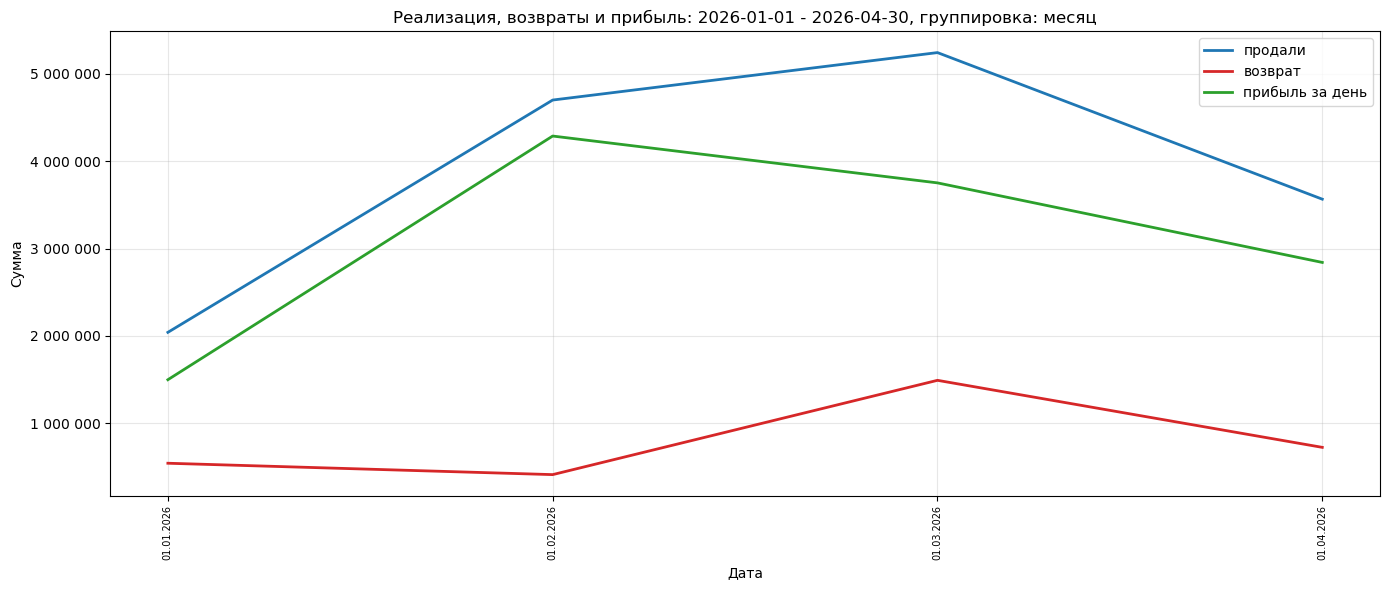

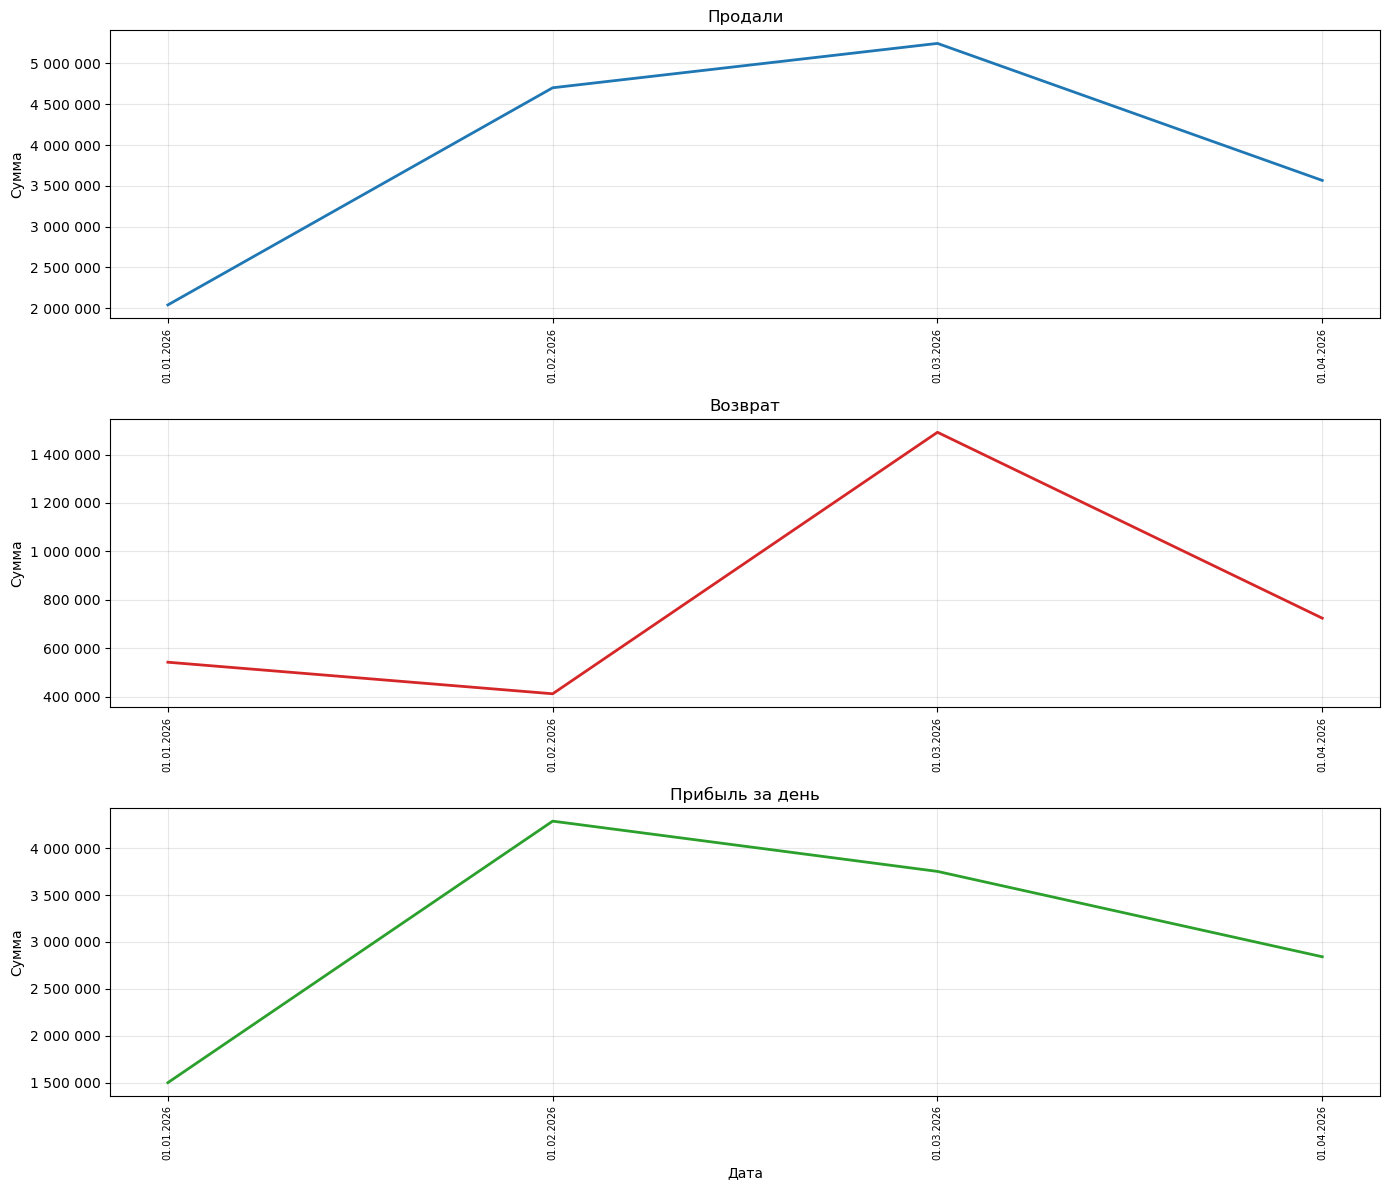

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

start_date = "2026-01-01"
end_date = "2026-04-30"
sales_graph_grouping = "месяц"  # варианты: "день", "неделя", "месяц", "квартал", "период"

period_sales = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(start_date, end_date)
].copy()

period_sales["date"] = period_sales["sale_date"].dt.normalize()
period_sales["продали"] = period_sales["amount"].where(
    period_sales["sales_doc_type"].eq("Реализация"), 0
)
period_sales["возврат"] = (-period_sales["amount"]).where(
    period_sales["sales_doc_type"].eq("Корректировка реализации"), 0
)

daily_sales = (
    period_sales
    .groupby("date", as_index=True)[["продали", "возврат"]]
    .sum()
    .reindex(pd.date_range(start_date, end_date, freq="D"), fill_value=0)
)
daily_sales["прибыль за день"] = daily_sales["продали"] - daily_sales["возврат"]

def aggregate_by_period(df, grouping, start_date, end_date):
    grouping = grouping.lower()
    if grouping not in {"день", "неделя", "месяц", "квартал", "период"}:
        raise ValueError('Группировка должна быть одной из: "день", "неделя", "месяц", "квартал", "период"')
    if grouping == "день":
        result = df.copy()
    elif grouping == "неделя":
        groups = df.index - pd.to_timedelta(df.index.weekday, unit="D")
        result = df.groupby(groups).sum()
    elif grouping == "месяц":
        groups = df.index.to_period("M").to_timestamp()
        result = df.groupby(groups).sum()
    elif grouping == "квартал":
        groups = df.index.to_period("Q").to_timestamp()
        result = df.groupby(groups).sum()
    else:
        result = pd.DataFrame(df.sum()).T
        result.index = [f"{start_date} - {end_date}"]
    result.index.name = grouping
    return result

sales_plot = aggregate_by_period(daily_sales, sales_graph_grouping, start_date, end_date)

display(sales_plot)

colors = {
    "продали": "#1f77b4",
    "возврат": "#d62728",
    "прибыль за день": "#2ca02c",
}

formatter = mticker.FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))

def format_date_axis(ax, labels):
    positions = range(len(labels))
    ax.set_xticks(list(positions))
    ax.set_xticklabels(
        [label.strftime("%d.%m.%Y") if hasattr(label, "strftime") else str(label) for label in labels],
        rotation=90,
        fontsize=7,
    )
    ax.tick_params(axis="x", labelbottom=True)

plot_x = range(len(sales_plot.index))
fig, ax = plt.subplots(figsize=(14, 6))
for column in ["продали", "возврат", "прибыль за день"]:
    ax.plot(plot_x, sales_plot[column], label=column, color=colors[column], linewidth=2)
ax.set_title(f"Реализация, возвраты и прибыль: {start_date} - {end_date}, группировка: {sales_graph_grouping}")
ax.set_xlabel("Дата")
ax.set_ylabel("Сумма")
ax.yaxis.set_major_formatter(formatter)
ax.grid(True, alpha=0.3)
ax.legend()
format_date_axis(ax, sales_plot.index)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, column in zip(axes, ["продали", "возврат", "прибыль за день"]):
    ax.plot(plot_x, sales_plot[column], color=colors[column], linewidth=2)
    ax.set_title(column.capitalize())
    ax.set_ylabel("Сумма")
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(True, alpha=0.3)
    format_date_axis(ax, sales_plot.index)

axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()



,продали,возврат,прибыль за день
месяц,,,
2026-01-01,2041419.0,542489.05,1498929.95
2026-02-01,4701630.0,412150.39,4289479.61
2026-03-01,5245108.0,1492042.82,3753065.18
2026-04-01,3566490.0,724354.98,2842135.02


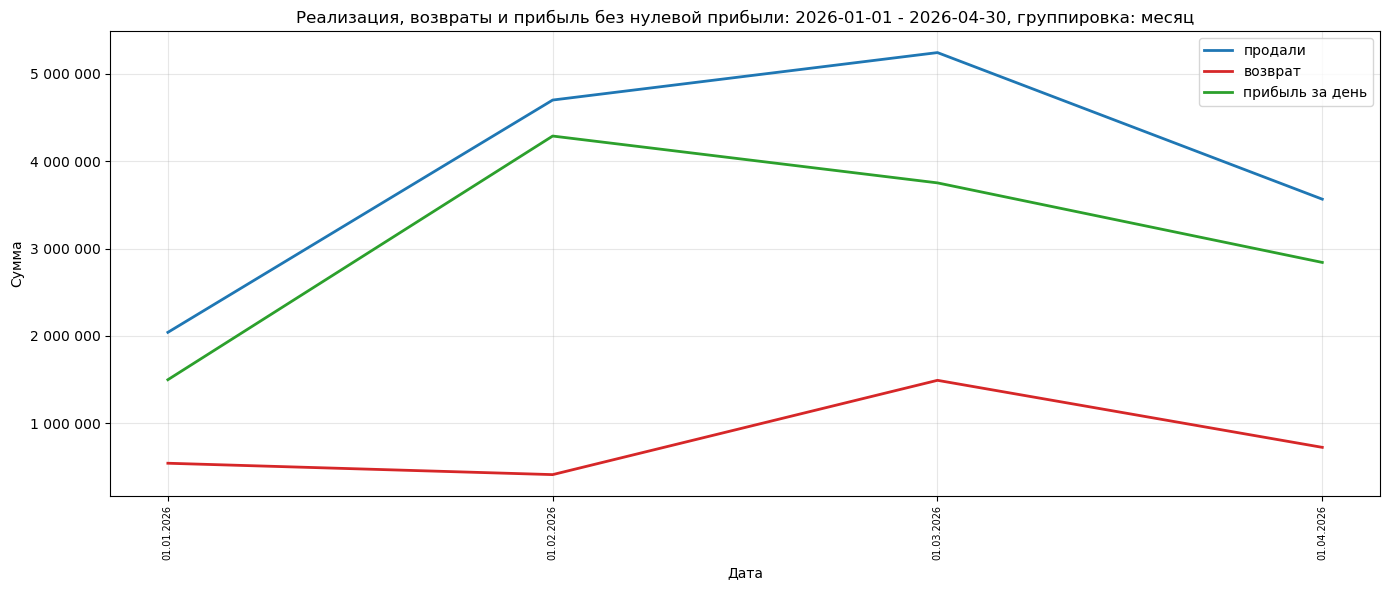

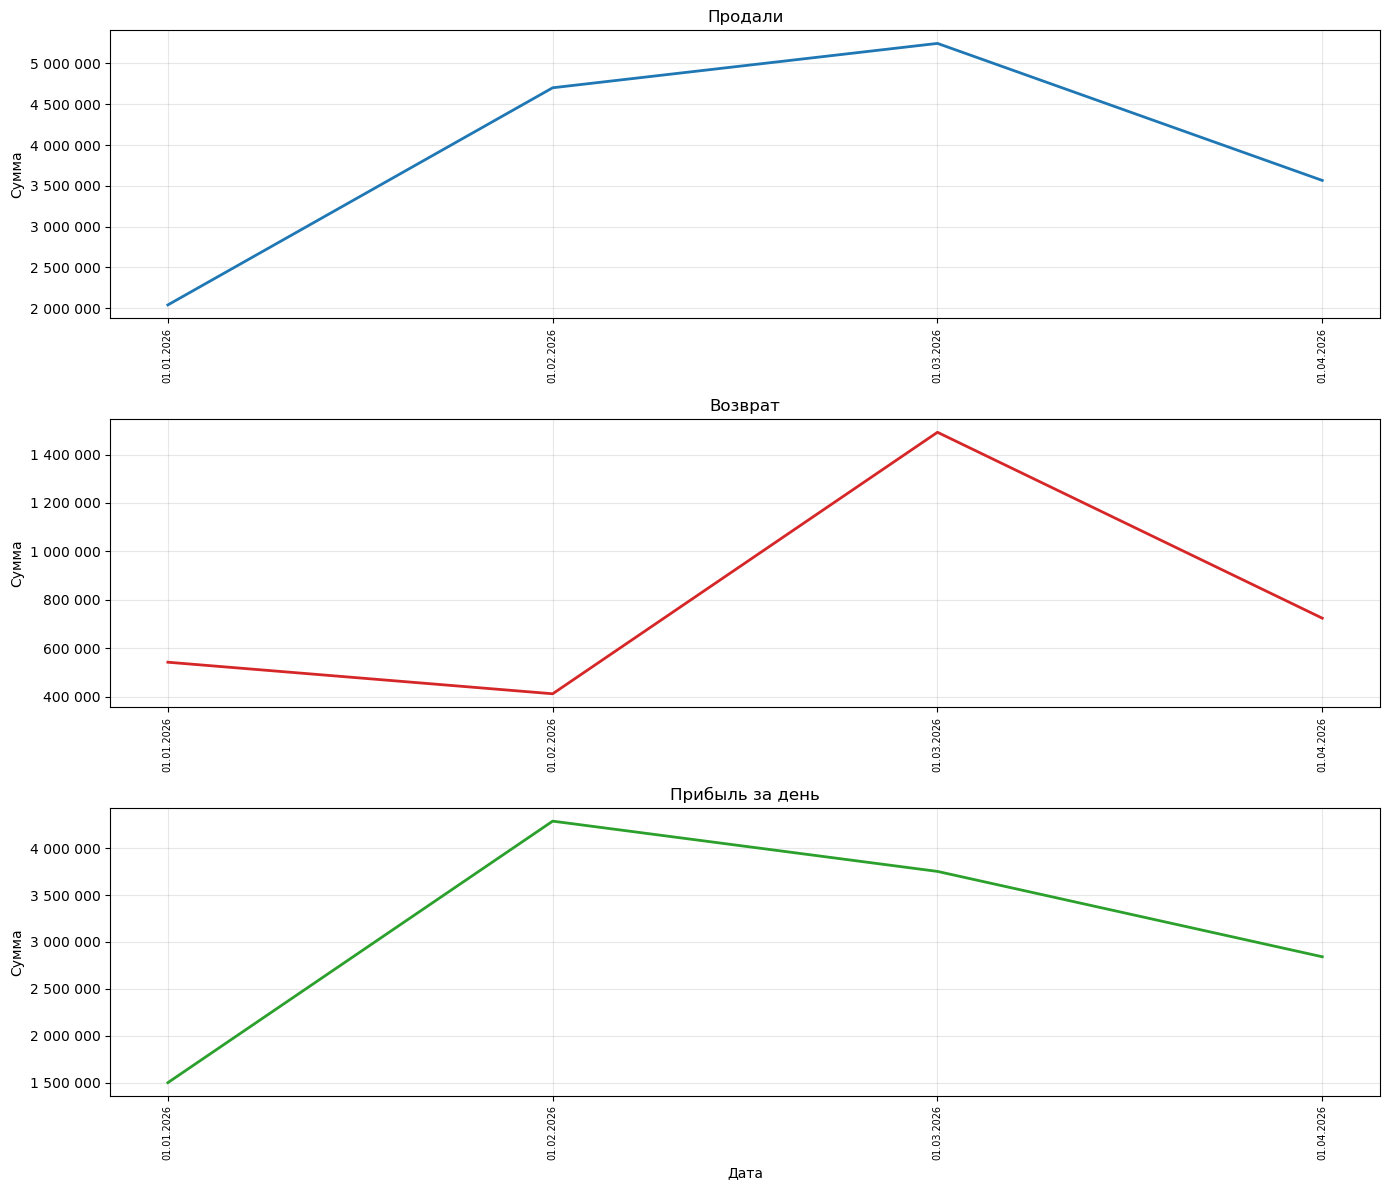

In [31]:
daily_sales_nonzero = daily_sales[daily_sales["прибыль за день"] != 0]
sales_nonzero_plot = aggregate_by_period(daily_sales_nonzero, sales_graph_grouping, start_date, end_date)

# После укрупнения периода сумма может стать нулевой, поэтому фильтруем еще раз.
sales_nonzero_plot = sales_nonzero_plot[sales_nonzero_plot["прибыль за день"] != 0]

display(sales_nonzero_plot)

plot_x = range(len(sales_nonzero_plot.index))
fig, ax = plt.subplots(figsize=(14, 6))
for column in ["продали", "возврат", "прибыль за день"]:
    ax.plot(plot_x, sales_nonzero_plot[column], label=column, color=colors[column], linewidth=2)
ax.set_title(f"Реализация, возвраты и прибыль без нулевой прибыли: {start_date} - {end_date}, группировка: {sales_graph_grouping}")
ax.set_xlabel("Дата")
ax.set_ylabel("Сумма")
ax.yaxis.set_major_formatter(formatter)
ax.grid(True, alpha=0.3)
ax.legend()
format_date_axis(ax, sales_nonzero_plot.index)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for ax, column in zip(axes, ["продали", "возврат", "прибыль за день"]):
    ax.plot(plot_x, sales_nonzero_plot[column], color=colors[column], linewidth=2)
    ax.set_title(column.capitalize())
    ax.set_ylabel("Сумма")
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(True, alpha=0.3)
    format_date_axis(ax, sales_nonzero_plot.index)

axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()



# Статистика приход и возвраты


,приход,продажи,возвраты,тотал,% возвратов от прихода
месяц,,,,,
2025-05-01,978948.80,1021916.00,1136051.00,-157102.20,116.048051
2025-06-01,1145115.02,2274957.00,633261.00,511854.02,55.301082
2025-07-01,1874679.72,4232569.00,246600.00,1628079.72,13.154247
2025-08-01,3891754.41,4120009.00,715560.00,3176194.41,18.386566
2025-09-01,3602062.26,5299088.00,625840.00,2976222.26,17.374491
2025-10-01,5768109.82,6999511.70,221333.23,5546776.59,3.837188
2025-11-01,5661947.73,5543321.72,298600.07,5363347.66,5.273805
2025-12-01,5146962.60,4534850.52,447940.82,4699021.78,8.703013
2026-01-01,2659441.20,2041419.00,542489.05,2116952.15,20.398610


,итого
приход,4.201052e+07
продажи,4.958087e+07
возвраты,7.496223e+06
тотал,3.451429e+07
% возвратов от прихода,1.784368e+01


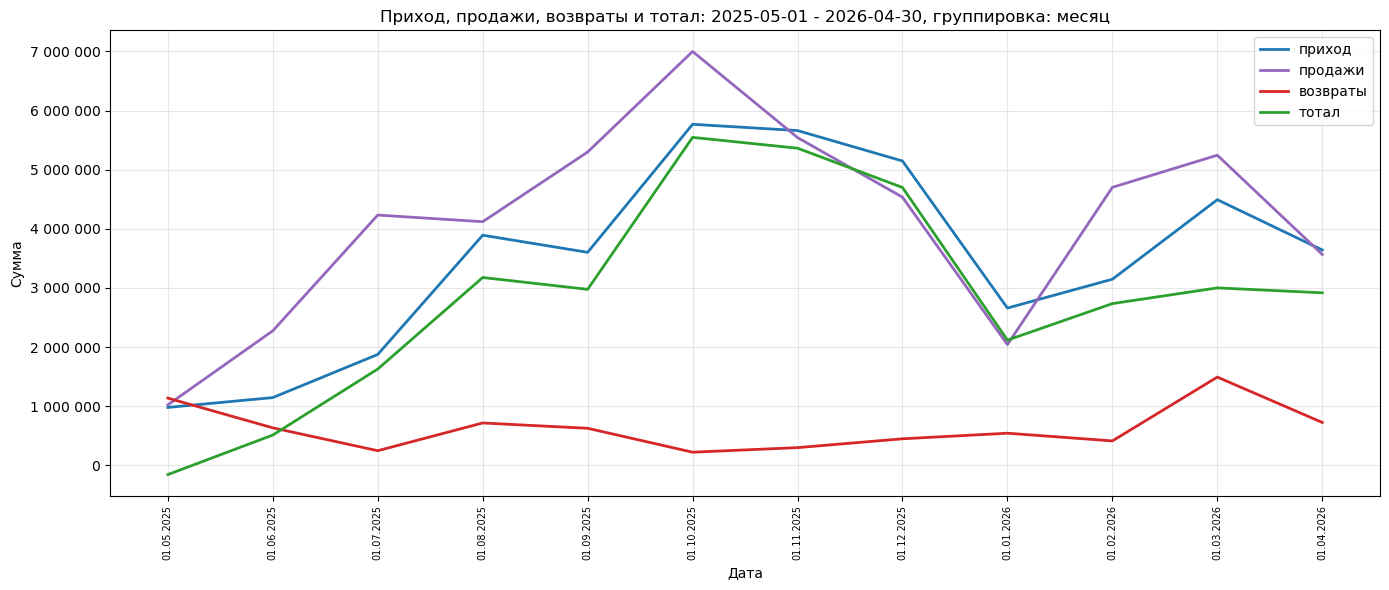

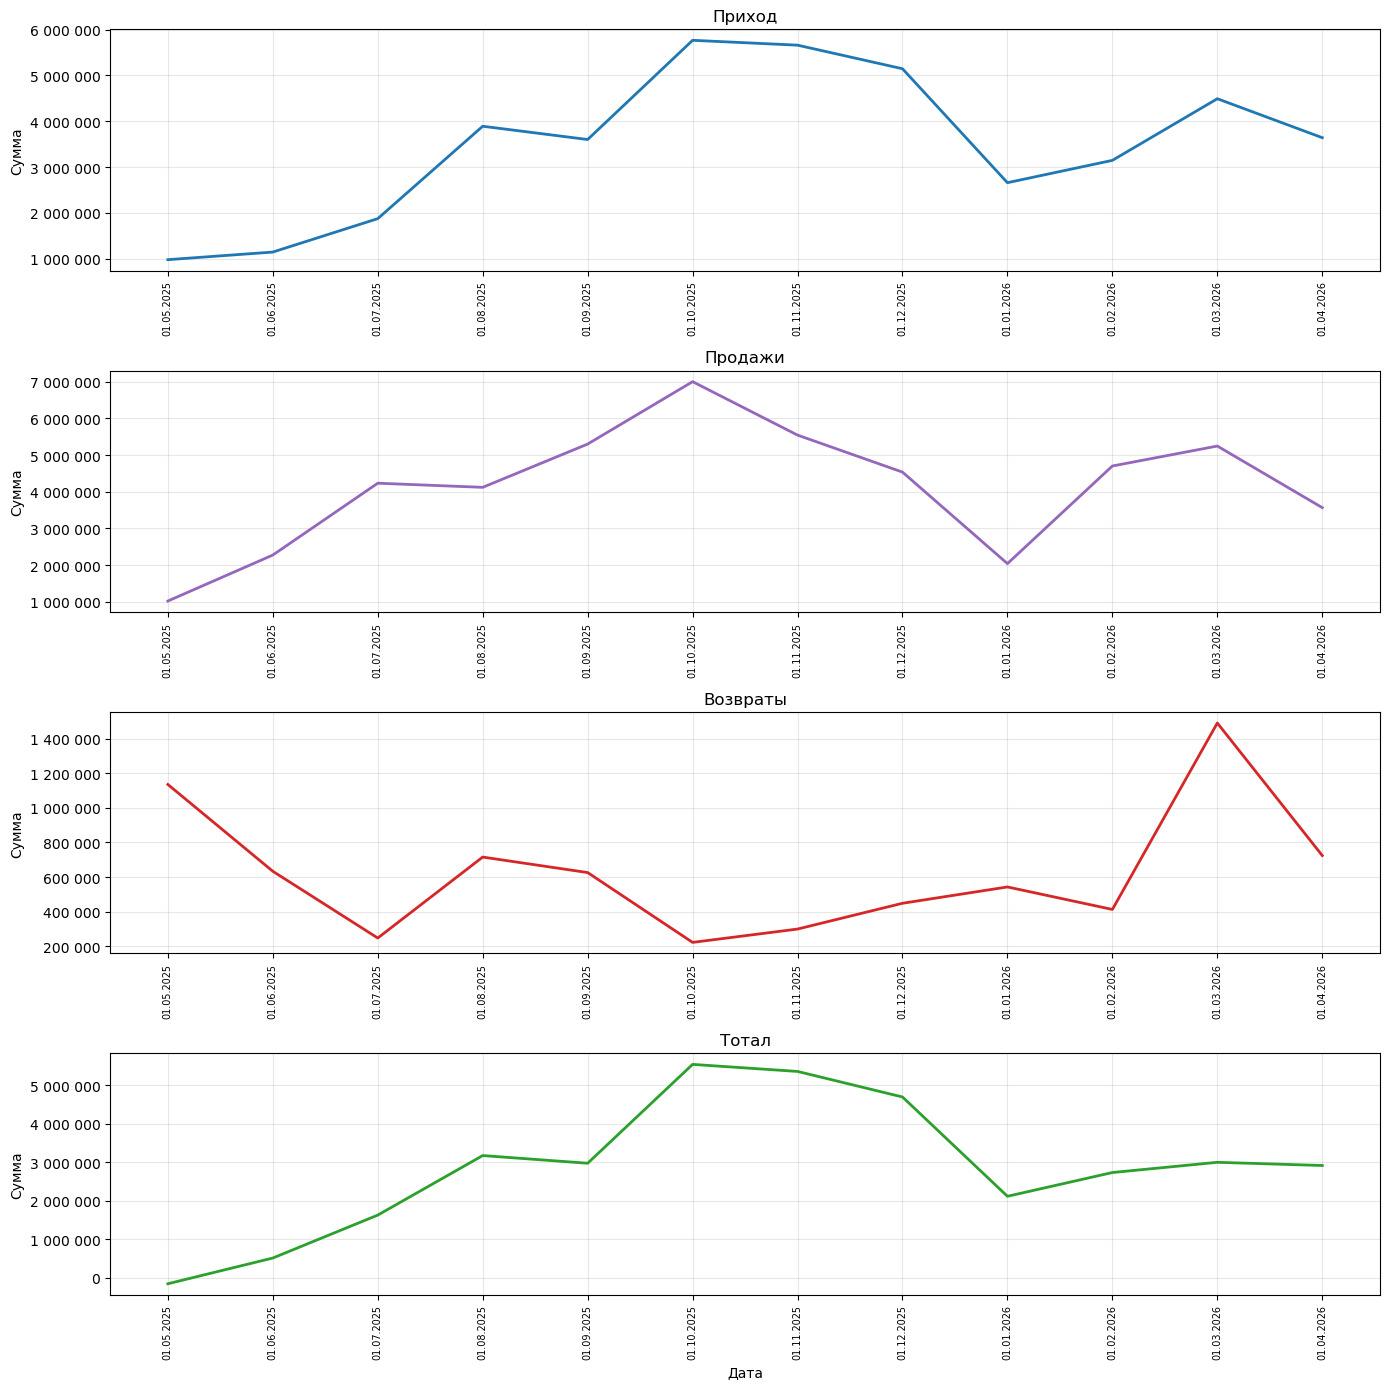

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

start_date = "2025-05-01"
end_date = "2026-04-30"
cashflow_graph_grouping = "месяц"  # варианты: "день", "неделя", "месяц", "квартал", "период"
date_index = pd.date_range(start_date, end_date, freq="D")

bank_period = bank_statement_transactions[
    bank_statement_transactions["operation_date"].between(start_date, end_date)
].copy()

bank_dedup_key = [
    "operation_date",
    "document_number",
    "amount",
    "direction",
    "counterparty_inn",
    "payment_purpose",
]
bank_period = bank_period.drop_duplicates(bank_dedup_key)

incoming_daily = (
    bank_period[bank_period["amount"] > 0]
    .assign(date=lambda df: df["operation_date"].dt.normalize())
    .groupby("date", as_index=True)["amount"]
    .sum()
    .reindex(date_index, fill_value=0)
)

sales_daily = (
    sales_by_counterparties[
        sales_by_counterparties["sale_date"].between(start_date, end_date)
        & sales_by_counterparties["sales_doc_type"].eq("Реализация")
    ]
    .assign(date=lambda df: df["sale_date"].dt.normalize())
    .groupby("date", as_index=True)["amount"]
    .sum()
    .reindex(date_index, fill_value=0)
)

returns_daily = (
    sales_by_counterparties[
        sales_by_counterparties["sale_date"].between(start_date, end_date)
        & sales_by_counterparties["sales_doc_type"].eq("Корректировка реализации")
    ]
    .assign(date=lambda df: df["sale_date"].dt.normalize(), возвраты=lambda df: -df["amount"])
    .groupby("date", as_index=True)["возвраты"]
    .sum()
    .reindex(date_index, fill_value=0)
)

cashflow_daily = pd.DataFrame({
    "приход": incoming_daily,
    "продажи": sales_daily,
    "возвраты": returns_daily,
})
cashflow_daily["тотал"] = cashflow_daily["приход"] - cashflow_daily["возвраты"]

def aggregate_by_period(df, grouping, start_date, end_date):
    grouping = grouping.lower()
    if grouping not in {"день", "неделя", "месяц", "квартал", "период"}:
        raise ValueError('Группировка должна быть одной из: "день", "неделя", "месяц", "квартал", "период"')
    if grouping == "день":
        result = df.copy()
    elif grouping == "неделя":
        groups = df.index - pd.to_timedelta(df.index.weekday, unit="D")
        result = df.groupby(groups).sum()
    elif grouping == "месяц":
        groups = df.index.to_period("M").to_timestamp()
        result = df.groupby(groups).sum()
    elif grouping == "квартал":
        groups = df.index.to_period("Q").to_timestamp()
        result = df.groupby(groups).sum()
    else:
        result = pd.DataFrame(df.sum()).T
        result.index = [f"{start_date} - {end_date}"]
    result.index.name = grouping
    return result

cashflow_plot = aggregate_by_period(cashflow_daily, cashflow_graph_grouping, start_date, end_date)
cashflow_plot["% возвратов от прихода"] = (
    cashflow_plot["возвраты"]
    .div(cashflow_plot["приход"].replace(0, pd.NA))
    .mul(100)
)

cashflow_totals = cashflow_plot[["приход", "продажи", "возвраты", "тотал"]].sum()
cashflow_totals["% возвратов от прихода"] = (
    cashflow_totals["возвраты"] / cashflow_totals["приход"] * 100
    if cashflow_totals["приход"] != 0
    else pd.NA
)

display(cashflow_plot)
display(cashflow_totals.to_frame("итого"))

cashflow_colors = {
    "приход": "#1f77b4",
    "продажи": "#9467bd",
    "возвраты": "#d62728",
    "тотал": "#2ca02c",
}

formatter = mticker.FuncFormatter(lambda value, _: f"{value:,.0f}".replace(",", " "))

def format_date_axis(ax, labels):
    positions = range(len(labels))
    ax.set_xticks(list(positions))
    ax.set_xticklabels(
        [label.strftime("%d.%m.%Y") if hasattr(label, "strftime") else str(label) for label in labels],
        rotation=90,
        fontsize=7,
    )
    ax.tick_params(axis="x", labelbottom=True)

plot_x = range(len(cashflow_plot.index))
fig, ax = plt.subplots(figsize=(14, 6))
for column in ["приход", "продажи", "возвраты", "тотал"]:
    ax.plot(plot_x, cashflow_plot[column], label=column, color=cashflow_colors[column], linewidth=2)
ax.set_title(f"Приход, продажи, возвраты и тотал: {start_date} - {end_date}, группировка: {cashflow_graph_grouping}")
ax.set_xlabel("Дата")
ax.set_ylabel("Сумма")
ax.yaxis.set_major_formatter(formatter)
ax.grid(True, alpha=0.3)
ax.legend()
format_date_axis(ax, cashflow_plot.index)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
for ax, column in zip(axes, ["приход", "продажи", "возвраты", "тотал"]):
    ax.plot(plot_x, cashflow_plot[column], color=cashflow_colors[column], linewidth=2)
    ax.set_title(column.capitalize())
    ax.set_ylabel("Сумма")
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(True, alpha=0.3)
    format_date_axis(ax, cashflow_plot.index)

axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()



In [33]:
report_start_date = "2025-06-01"
report_end_date = "2026-04-30"
report_grouping = "месяц"  # варианты: "день", "неделя", "месяц"

report_grouping = report_grouping.lower()
if report_grouping not in {"день", "неделя", "месяц"}:
    raise ValueError('report_grouping должен быть одним из значений: "день", "неделя", "месяц"')

report_date_index = pd.date_range(report_start_date, report_end_date, freq="D")

bank_report = bank_statement_transactions[
    bank_statement_transactions["operation_date"].between(report_start_date, report_end_date)
].copy()

bank_dedup_key = [
    "operation_date",
    "document_number",
    "amount",
    "direction",
    "counterparty_inn",
    "payment_purpose",
]
bank_report = bank_report.drop_duplicates(bank_dedup_key)

incoming_by_day = (
    bank_report[bank_report["amount"] > 0]
    .assign(date=lambda df: df["operation_date"].dt.normalize())
    .groupby("date", as_index=True)["amount"]
    .sum()
    .reindex(report_date_index, fill_value=0)
)

sales_by_day = (
    sales_by_counterparties[
        sales_by_counterparties["sale_date"].between(report_start_date, report_end_date)
        & sales_by_counterparties["sales_doc_type"].eq("Реализация")
    ]
    .assign(date=lambda df: df["sale_date"].dt.normalize())
    .groupby("date", as_index=True)["amount"]
    .sum()
    .reindex(report_date_index, fill_value=0)
)

returns_by_day = (
    sales_by_counterparties[
        sales_by_counterparties["sale_date"].between(report_start_date, report_end_date)
        & sales_by_counterparties["sales_doc_type"].eq("Корректировка реализации")
    ]
    .assign(date=lambda df: df["sale_date"].dt.normalize(), возвраты=lambda df: -df["amount"])
    .groupby("date", as_index=True)["возвраты"]
    .sum()
    .reindex(report_date_index, fill_value=0)
)

comparison_by_day = pd.DataFrame({
    "приход": incoming_by_day,
    "продажи": sales_by_day,
    "возвраты": returns_by_day,
})

if report_grouping == "день":
    comparison_table = comparison_by_day.copy()
elif report_grouping == "неделя":
    week_start = comparison_by_day.index - pd.to_timedelta(comparison_by_day.index.weekday, unit="D")
    comparison_table = comparison_by_day.groupby(week_start).sum()
else:
    month_start = comparison_by_day.index.to_period("M").to_timestamp()
    comparison_table = comparison_by_day.groupby(month_start).sum()

comparison_table["тотал"] = comparison_table["приход"] - comparison_table["возвраты"]
comparison_table["% возвратов от прихода"] = (
    comparison_table["возвраты"]
    .div(comparison_table["приход"].replace(0, pd.NA))
    .mul(100)
)
comparison_table.index.name = report_grouping

comparison_totals = comparison_table[["приход", "продажи", "возвраты", "тотал"]].sum()
comparison_totals["% возвратов от прихода"] = (
    comparison_totals["возвраты"] / comparison_totals["приход"] * 100
    if comparison_totals["приход"] != 0
    else pd.NA
)

display(comparison_table)
display(comparison_totals.to_frame("итого"))



,приход,продажи,возвраты,тотал,% возвратов от прихода
месяц,,,,,
2025-06-01,1145115.02,2274957.00,633261.00,511854.02,55.301082
2025-07-01,1874679.72,4232569.00,246600.00,1628079.72,13.154247
2025-08-01,3891754.41,4120009.00,715560.00,3176194.41,18.386566
2025-09-01,3602062.26,5299088.00,625840.00,2976222.26,17.374491
2025-10-01,5768109.82,6999511.70,221333.23,5546776.59,3.837188
2025-11-01,5661947.73,5543321.72,298600.07,5363347.66,5.273805
2025-12-01,5146962.60,4534850.52,447940.82,4699021.78,8.703013
2026-01-01,2659441.20,2041419.00,542489.05,2116952.15,20.398610
2026-02-01,3147109.31,4701630.00,412150.39,2734958.92,13.096157


,итого
приход,4.103157e+07
продажи,4.855895e+07
возвраты,6.360172e+06
тотал,3.467140e+07
% возвратов от прихода,1.550068e+01


# Анализ возвратов


In [36]:
returns_start_date = "2025-06-01"
returns_end_date = "2026-04-30"
returns_grouping = "период"  # варианты: "день", "неделя", "месяц", "квартал", "период"
returns_top_n = 20

returns_grouping = returns_grouping.lower()
if returns_grouping not in {"день", "неделя", "месяц", "квартал", "период"}:
    raise ValueError('returns_grouping должен быть одним из значений: "день", "неделя", "месяц", "квартал", "период"')

returns_period = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(returns_start_date, returns_end_date)
    & sales_by_counterparties["sales_doc_type"].eq("Корректировка реализации")
].copy()

returns_period["date"] = returns_period["sale_date"].dt.normalize()
returns_period["возврат"] = -returns_period["amount"]
returns_period["количество возврата"] = -returns_period["quantity"]

if returns_grouping == "день":
    returns_period["группа"] = returns_period["date"]
elif returns_grouping == "неделя":
    returns_period["группа"] = returns_period["date"] - pd.to_timedelta(returns_period["date"].dt.weekday, unit="D")
elif returns_grouping == "месяц":
    returns_period["группа"] = returns_period["date"].dt.to_period("M").dt.to_timestamp()
elif returns_grouping == "квартал":
    returns_period["группа"] = returns_period["date"].dt.to_period("Q").dt.to_timestamp()
else:
    returns_period["группа"] = f"{returns_start_date} - {returns_end_date}"

returns_by_counterparty = (
    returns_period
    .groupby(["группа", "counterparty_raw"], dropna=False)
    .agg(
        возврат=("возврат", "sum"),
        количество_возврата=("количество возврата", "sum"),
        документов=("sales_doc_raw", "nunique"),
        строк=("sales_doc_raw", "size"),
    )
    .reset_index()
    .sort_values(["группа", "возврат"], ascending=[True, False])
    .groupby("группа", group_keys=False)
    .head(returns_top_n)
)

returns_by_nomenclature = (
    returns_period
    .groupby(["группа", "nomenclature"], dropna=False)
    .agg(
        возврат=("возврат", "sum"),
        количество_возврата=("количество возврата", "sum"),
        документов=("sales_doc_raw", "nunique"),
        контрагентов=("counterparty_raw", "nunique"),
        строк=("sales_doc_raw", "size"),
    )
    .reset_index()
    .sort_values(["группа", "возврат"], ascending=[True, False])
    .groupby("группа", group_keys=False)
    .head(returns_top_n)
)

display(returns_period[["возврат", "количество возврата"]].sum().to_frame("итого"))

display(returns_by_counterparty)
display(returns_by_nomenclature)




,итого
возврат,6360172.36
количество возврата,29971.00


,группа,counterparty_raw,возврат,количество_возврата,документов,строк
137,2025-06-01 - 2026-04-30,Торгсервис 71 ООО Магазин Светофор Киреевский ...,107898.20,546.0,4,6
168,2025-06-01 - 2026-04-30,Торгсервис 71 ООО Магазин Светофор г. Ясногорс...,103366.20,507.0,10,10
167,2025-06-01 - 2026-04-30,"Торгсервис 71 ООО Магазин Светофор г. Щекино, ...",93674.40,458.0,9,10
160,2025-06-01 - 2026-04-30,"Торгсервис 71 ООО Магазин Светофор г. Тула, п....",91581.00,451.0,6,7
152,2025-06-01 - 2026-04-30,Торгсервис 71 ООО Магазин Светофор г. Новомоск...,83054.40,408.0,6,7
145,2025-06-01 - 2026-04-30,"Торгсервис 71 ООО Магазин Светофор г. Донской,...",82911.80,404.0,8,9
173,2025-06-01 - 2026-04-30,"Торгсервис 71 ООО Магазин Светофор, г. Суворов...",82438.80,396.0,8,9
71,2025-06-01 - 2026-04-30,Торгсервис 150 ООО Магазин Светофор г. Серпухо...,81462.00,384.0,6,7
163,2025-06-01 - 2026-04-30,"Торгсервис 71 ООО Магазин Светофор г. Тула, ул...",80092.60,397.0,6,7
69,2025-06-01 - 2026-04-30,"Торгсервис 150 ООО Магазин Светофор г. Руза, п...",80058.00,370.0,5,6


,группа,nomenclature,возврат,количество_возврата,документов,контрагентов,строк
7,2025-06-01 - 2026-04-30,"Изделия хлебобулочные маффин ""Каприз"" с изюмом...",2939827.50,13711.0,218,101,218
9,2025-06-01 - 2026-04-30,"Изделия хлебобулочные""Мадлены "" ассорти с начи...",1018268.70,5006.0,91,33,91
11,2025-06-01 - 2026-04-30,"Сдобное хлебобулочное изделие ""ДИВНОЕ""с начинк...",594910.00,2827.0,64,22,64
2,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""Мечта"" 1,0 кг",383400.00,1917.0,26,26,26
0,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""Кокетка "" с ванильной н...",294250.00,1177.0,85,59,85
4,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""Улыбка "" песочное 1,0 кг",268373.40,1406.0,40,26,40
1,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""МАЭСТРО"" песочное 1,0 кг",210126.76,1113.0,55,27,55
5,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начи...",203191.00,796.0,61,43,61
13,2025-06-01 - 2026-04-30,"Хлебобулочное изделие бисквитное ""Мадлены""с из...",142715.00,677.0,26,10,26
3,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""НЕЖЕНКА"" с ванильной на...",120640.00,464.0,30,22,30


## Продажи по номенклатуре


In [37]:
sales_items_start_date = "2025-06-01"
sales_items_end_date = "2026-04-30"
sales_items_grouping = "период"  # варианты: "день", "неделя", "месяц", "квартал", "период"
sales_items_top_n = 30

sales_items_grouping = sales_items_grouping.lower()
if sales_items_grouping not in {"день", "неделя", "месяц", "квартал", "период"}:
    raise ValueError('sales_items_grouping должен быть одним из значений: "день", "неделя", "месяц", "квартал", "период"')

sales_items_period = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(sales_items_start_date, sales_items_end_date)
    & sales_by_counterparties["sales_doc_type"].eq("Реализация")
].copy()

sales_items_period["date"] = sales_items_period["sale_date"].dt.normalize()
sales_items_period["продали"] = sales_items_period["amount"]
sales_items_period["количество продали"] = sales_items_period["quantity"]

if sales_items_grouping == "день":
    sales_items_period["группа"] = sales_items_period["date"]
elif sales_items_grouping == "неделя":
    sales_items_period["группа"] = sales_items_period["date"] - pd.to_timedelta(sales_items_period["date"].dt.weekday, unit="D")
elif sales_items_grouping == "месяц":
    sales_items_period["группа"] = sales_items_period["date"].dt.to_period("M").dt.to_timestamp()
elif sales_items_grouping == "квартал":
    sales_items_period["группа"] = sales_items_period["date"].dt.to_period("Q").dt.to_timestamp()
else:
    sales_items_period["группа"] = f"{sales_items_start_date} - {sales_items_end_date}"

sales_by_nomenclature = (
    sales_items_period
    .groupby(["группа", "nomenclature"], dropna=False)
    .agg(
        продали=("продали", "sum"),
        количество_продали=("количество продали", "sum"),
        документов=("sales_doc_raw", "nunique"),
        контрагентов=("counterparty_raw", "nunique"),
        строк=("sales_doc_raw", "size"),
    )
    .reset_index()
    .sort_values(["группа", "продали"], ascending=[True, False])
    .groupby("группа", group_keys=False)
    .head(sales_items_top_n)
)

display(sales_items_period[["продали", "количество продали"]].sum().to_frame("итого"))
display(sales_by_nomenclature)



,итого
продали,48558953.94
количество продали,218682.00


,группа,nomenclature,продали,количество_продали,документов,контрагентов,строк
5,2025-06-01 - 2026-04-30,"Изделия хлебобулочные маффин ""Каприз"" с изюмом...",15515130.00,71744.0,385,109,385
4,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начи...",8378550.00,32670.0,490,121,490
0,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""Кокетка "" с ванильной н...",7355750.00,29423.0,419,106,419
7,2025-06-01 - 2026-04-30,"Изделия хлебобулочные""Мадлены "" ассорти с начи...",5990239.20,29589.0,170,41,171
3,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""Улыбка "" песочное 1,0 кг",4008716.64,20899.0,120,41,121
1,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""МАЭСТРО"" песочное 1,0 кг",2427381.10,12729.0,96,31,96
9,2025-06-01 - 2026-04-30,"Сдобное хлебобулочное изделие ""ДИВНОЕ""с начинк...",2381872.00,11390.0,79,22,79
2,2025-06-01 - 2026-04-30,"Изделия хлебобулочные ""НЕЖЕНКА"" с ванильной на...",1097720.00,4222.0,63,25,63
10,2025-06-01 - 2026-04-30,"Хлебобулочное изделие бисквитное ""Мадлены""с из...",588645.00,2795.0,29,8,29
8,2025-06-01 - 2026-04-30,"Пирожное слоеное ""Сувенир"" 1,0 кг",562750.00,2251.0,43,43,43


## Сравнение продали и вернули по номенклатуре


In [40]:
items_compare_start_date = "2025-09-01"
items_compare_end_date = "2025-12-31"
items_compare_grouping = "период"  # варианты: "день", "неделя", "месяц", "квартал", "период"
items_compare_top_n = 30

items_compare_grouping = items_compare_grouping.lower()
if items_compare_grouping not in {"день", "неделя", "месяц", "квартал", "период"}:
    raise ValueError('items_compare_grouping должен быть одним из значений: "день", "неделя", "месяц", "квартал", "период"')

items_compare = sales_by_counterparties[
    sales_by_counterparties["sale_date"].between(items_compare_start_date, items_compare_end_date)
    & sales_by_counterparties["sales_doc_type"].isin(["Реализация", "Корректировка реализации"])
].copy()

items_compare["date"] = items_compare["sale_date"].dt.normalize()
items_compare["продали"] = items_compare["amount"].where(items_compare["sales_doc_type"].eq("Реализация"), 0)
items_compare["вернули"] = (-items_compare["amount"]).where(items_compare["sales_doc_type"].eq("Корректировка реализации"), 0)
items_compare["количество продали"] = items_compare["quantity"].where(items_compare["sales_doc_type"].eq("Реализация"), 0)
items_compare["количество вернули"] = (-items_compare["quantity"]).where(items_compare["sales_doc_type"].eq("Корректировка реализации"), 0)

if items_compare_grouping == "день":
    items_compare["группа"] = items_compare["date"]
elif items_compare_grouping == "неделя":
    items_compare["группа"] = items_compare["date"] - pd.to_timedelta(items_compare["date"].dt.weekday, unit="D")
elif items_compare_grouping == "месяц":
    items_compare["группа"] = items_compare["date"].dt.to_period("M").dt.to_timestamp()
elif items_compare_grouping == "квартал":
    items_compare["группа"] = items_compare["date"].dt.to_period("Q").dt.to_timestamp()
else:
    items_compare["группа"] = f"{items_compare_start_date} - {items_compare_end_date}"

items_compare_table = (
    items_compare
    .groupby(["группа", "nomenclature"], dropna=False)
    .agg(
        продали=("продали", "sum"),
        вернули=("вернули", "sum"),
        количество_продали=("количество продали", "sum"),
        количество_вернули=("количество вернули", "sum"),
        документов=("sales_doc_raw", "nunique"),
        контрагентов=("counterparty_raw", "nunique"),
        строк=("sales_doc_raw", "size"),
    )
    .reset_index()
)
items_compare_table["нетто"] = items_compare_table["продали"] - items_compare_table["вернули"]
items_compare_table["% возврата от продаж"] = (
    items_compare_table["вернули"]
    .div(items_compare_table["продали"].replace(0, pd.NA))
    .mul(100)
)
items_compare_table["% количества возврата"] = (
    items_compare_table["количество_вернули"]
    .div(items_compare_table["количество_продали"].replace(0, pd.NA))
    .mul(100)
)

items_compare_table = (
    items_compare_table
    .sort_values(["группа", "вернули", "продали"], ascending=[True, False, False])
    .groupby("группа", group_keys=False)
    .head(items_compare_top_n)
)

items_compare_totals = items_compare_table[["продали", "вернули", "нетто", "количество_продали", "количество_вернули"]].sum()
items_compare_totals["% возврата от продаж"] = (
    items_compare_totals["вернули"] / items_compare_totals["продали"] * 100
    if items_compare_totals["продали"] != 0
    else pd.NA
)
items_compare_totals["% количества возврата"] = (
    items_compare_totals["количество_вернули"] / items_compare_totals["количество_продали"] * 100
    if items_compare_totals["количество_продали"] != 0
    else pd.NA
)

display(items_compare_totals.to_frame("итого по показанному топу"))
display(items_compare_table)



,итого по показанному топу
продали,2.237677e+07
вернули,1.593714e+06
нетто,2.078306e+07
количество_продали,1.009200e+05
количество_вернули,7.268000e+03
% возврата от продаж,7.122181e+00
% количества возврата,7.201744e+00


,группа,nomenclature,продали,вернули,количество_продали,количество_вернули,документов,контрагентов,строк,нетто,% возврата от продаж,% количества возврата
5,2025-09-01 - 2025-12-31,"Изделия хлебобулочные маффин ""Каприз"" с изюмом...",7793060.00,595980.00,35540.0,2709.0,257,105,257,7197080.00,7.647574,7.622397
0,2025-09-01 - 2025-12-31,"Изделия хлебобулочные ""Кокетка "" с ванильной н...",5750500.00,271500.00,23002.0,1086.0,387,103,387,5479000.00,4.721329,4.721329
6,2025-09-01 - 2025-12-31,"Изделия хлебобулочные""Мадлены "" ассорти с начи...",2467210.20,248113.00,12230.0,1241.0,104,40,104,2219097.20,10.056419,10.147179
3,2025-09-01 - 2025-12-31,"Изделия хлебобулочные ""Улыбка "" песочное 1,0 кг",1729216.64,144519.38,9064.0,752.0,76,40,76,1584697.26,8.357506,8.296558
2,2025-09-01 - 2025-12-31,"Изделия хлебобулочные ""НЕЖЕНКА"" с ванильной на...",1004120.00,120640.00,3862.0,464.0,87,25,87,883480.00,12.014500,12.014500
7,2025-09-01 - 2025-12-31,"Сдобное хлебобулочное изделие ""ДИВНОЕ""с начинк...",1187840.00,106289.20,5800.0,519.0,54,22,54,1081550.80,8.948107,8.948276
4,2025-09-01 - 2025-12-31,"Изделия хлебобулочные ""ЭТЮД "" с ванильной начи...",1132500.00,50000.00,4530.0,200.0,78,65,78,1082500.00,4.415011,4.415011
1,2025-09-01 - 2025-12-31,"Изделия хлебобулочные ""МАЭСТРО"" песочное 1,0 кг",1092491.10,48392.54,5830.0,257.0,56,27,56,1044098.56,4.429559,4.408233
8,2025-09-01 - 2025-12-31,"Хлебобулочное изделие бисквитное ""Мадлены""с из...",219834.00,8280.00,1062.0,40.0,13,6,13,211554.00,3.766478,3.766478


Каприз - Кекс с изюмом
Мадлены - Кекс с изюмом
Дивное - песочка
Этюд - коса
Кокетка - Коса
Улыбка - песочка